# Multi-Period Renewable Grid Optimisation

This notebook extends the initial single-period experiment to a more realistic time-dependent unit-commitment problem.

Electricity demand and renewable availability change between scheduling periods. Thermal generator decisions are also interconnected because startup costs, ramping limits, and minimum operating durations affect future decisions.

We develop a 24-period classical scheduling model, followed by a smaller time-dependent quantum optimisation experiment.

The original RTS-GMLC benchmark is explored before constructing the reduced multi-period instance.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
with open("../data/2020-01-27.json", "r") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['time_periods', 'demand', 'reserves', 'thermal_generators', 'renewable_generators'])


In [3]:
demand_df = pd.DataFrame({
    "Period": range(1, 49),
    "Demand (MW)": data["demand"],
    "Reserve (MW)": data["reserves"]
})

display(demand_df)

,Period,Demand (MW),Reserve (MW)
0,1,3262.31,97.8693
1,2,3215.96,96.4788
2,3,3220.90,96.6270
3,4,3274.01,98.2203
4,5,3435.74,103.0722
5,6,3779.83,113.3949
6,7,4116.21,123.4863
7,8,4094.34,122.8302
8,9,4076.64,122.2992
9,10,4063.94,121.9182


In [4]:
thermal = pd.DataFrame.from_dict(
    data["thermal_generators"],
    orient="index"
)

display(thermal)

,must_run,power_output_minimum,power_output_maximum,ramp_up_limit,ramp_down_limit,ramp_startup_limit,ramp_shutdown_limit,time_up_minimum,time_down_minimum,power_output_t0,unit_on_t0,time_down_t0,time_up_t0,startup,piecewise_production,name
115_STEAM_1,0,5.0,12.0,20.0,20.0,5.0,5.0,4,2,0.0,0,168,0,"[{'lag': 2, 'cost': 393.28}, {'lag': 4, 'cost'...","[{'mw': 5.0, 'cost': 897.29}, {'mw': 7.33, 'co...",115_STEAM_1
101_CT_1,0,8.0,20.0,60.0,60.0,8.0,8.0,1,1,0.0,0,28,0,"[{'lag': 1, 'cost': 51.75}]","[{'mw': 8.0, 'cost': 1085.78}, {'mw': 12.0, 'c...",101_CT_1
101_CT_2,0,8.0,20.0,60.0,60.0,8.0,8.0,1,1,0.0,0,28,0,"[{'lag': 1, 'cost': 51.75}]","[{'mw': 8.0, 'cost': 1085.78}, {'mw': 12.0, 'c...",101_CT_2
213_CT_2,0,22.0,55.0,74.0,74.0,22.0,22.0,3,3,0.0,0,168,0,"[{'lag': 3, 'cost': 5665.23}]","[{'mw': 22.0, 'cost': 1122.43}, {'mw': 33.0, '...",213_CT_2
301_CT_1,0,8.0,20.0,60.0,60.0,8.0,8.0,1,1,0.0,0,168,0,"[{'lag': 1, 'cost': 51.75}]","[{'mw': 8.0, 'cost': 1208.23}, {'mw': 12.0, 'c...",301_CT_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102_STEAM_4,0,30.0,76.0,40.0,40.0,30.0,30.0,8,4,30.0,1,0,168,"[{'lag': 4, 'cost': 7144.02}, {'lag': 10, 'cos...","[{'mw': 30.0, 'cost': 735.1}, {'mw': 45.33, 'c...",102_STEAM_4
123_STEAM_2,0,62.0,155.0,60.0,60.0,62.0,62.0,8,8,62.0,1,0,168,"[{'lag': 8, 'cost': 14569.83}, {'lag': 11, 'co...","[{'mw': 62.0, 'cost': 1437.42}, {'mw': 93.0, '...",123_STEAM_2
223_CT_5,0,22.0,55.0,74.0,74.0,22.0,22.0,3,3,0.0,0,168,0,"[{'lag': 3, 'cost': 5665.23}]","[{'mw': 22.0, 'cost': 1692.76}, {'mw': 33.0, '...",223_CT_5
201_CT_2,0,8.0,20.0,60.0,60.0,8.0,8.0,1,1,0.0,0,168,0,"[{'lag': 1, 'cost': 51.75}]","[{'mw': 8.0, 'cost': 1157.23}, {'mw': 12.0, 'c...",201_CT_2


In [5]:
renewable = pd.DataFrame.from_dict(
    data["renewable_generators"],
    orient="index"
)

display(renewable)

,power_output_minimum,power_output_maximum,name
118_RTPV_9,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 4.1, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 4.1, ...",118_RTPV_9
101_PV_3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 16.5, 20.0...",101_PV_3
314_PV_2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 26.5, 35.5...",314_PV_2
215_PV_1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 69.4, 87.1...",215_PV_1
118_RTPV_4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 3.8, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8, 3.8, ...",118_RTPV_4
...,...,...,...
317_WIND_1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[750.0, 793.4, 799.1, 799.1, 796.6, 785.2, 793...",317_WIND_1
101_PV_1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 16.0, 19.1...",101_PV_1
212_CSP_1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",212_CSP_1
322_HYDRO_3,"[10.3, 23.9, 25.0, 15.6, 14.2, 4.8, 6.1, 24.8,...","[10.3, 23.9, 25.0, 15.6, 14.2, 4.8, 6.1, 24.8,...",322_HYDRO_3


## Construction of the Multi-Period Test System

We select 20 thermal generators and seven renewable generators from the original benchmark and retain the first 24 scheduling periods.

Demand and reserve requirements are scaled according to the selected thermal capacity. The selected wind and solar generation profiles remain time-dependent.

The resulting model includes changing electricity demand, renewable availability, thermal operating constraints, startup information, and generator production costs.

Net load is calculated as demand minus available renewable generation. It represents the thermal generation required if all available renewable electricity is utilised.

The reduced instance is saved as `data/multi_period_instance.json` for subsequent optimisation.

In [6]:
# Load original dataset
source_path = Path("../data/2020-01-27.json")

if not source_path.exists():
    source_path = Path("data/2020-01-27.json")

with open(source_path) as f:
    original = json.load(f)

# Retain original six generators and add fourteen more
thermal_ids = [
    "221_CC_1", "202_STEAM_3", "101_STEAM_4",
    "315_CT_6", "213_CT_1", "101_CT_1",
    "118_CC_1", "313_CC_1", "107_CC_1",
    "223_STEAM_1", "216_STEAM_1", "115_STEAM_3",
    "315_CT_7", "123_CT_1", "301_CT_3",
    "101_CT_2", "201_CT_2", "307_CT_1",
    "322_CT_5", "302_CT_3"
]

renewable_ids = [
    "309_WIND_1", "317_WIND_1",
    "101_PV_3", "314_PV_2", "215_PV_1",
    "324_PV_2", "310_PV_1"
]

T = 24

thermal_units = {
    name: original["thermal_generators"][name]
    for name in thermal_ids
}

renewable_units = {}

for name in renewable_ids:
    g = original["renewable_generators"][name].copy()
    g["power_output_minimum"] = g["power_output_minimum"][:T]
    g["power_output_maximum"] = g["power_output_maximum"][:T]
    renewable_units[name] = g

# Scale demand according to selected thermal capacity
total_capacity = sum(
    g["power_output_maximum"]
    for g in original["thermal_generators"].values()
)

selected_capacity = sum(
    g["power_output_maximum"]
    for g in thermal_units.values()
)

scale = selected_capacity / total_capacity

demand = np.array(original["demand"][:T]) * scale
reserves = np.array(original["reserves"][:T]) * scale

# Renewable availability by period
renewable_df = pd.DataFrame({
    name: g["power_output_maximum"]
    for name, g in renewable_units.items()
})

wind_ids = [name for name in renewable_ids if "WIND" in name]
solar_ids = [name for name in renewable_ids if "_PV_" in name]

profile = pd.DataFrame({
    "Period": np.arange(1, T + 1),
    "Demand_MW": demand,
    "Reserve_MW": reserves,
    "Wind_MW": renewable_df[wind_ids].sum(axis=1),
    "Solar_MW": renewable_df[solar_ids].sum(axis=1)
})

profile["Renewable_MW"] = (
    profile["Wind_MW"] + profile["Solar_MW"]
)

profile["Net_Load_MW"] = (
    profile["Demand_MW"] - profile["Renewable_MW"]
)

# Generator summary table
thermal_table = pd.DataFrame([
    {
        "Generator": name,
        "Min_MW": g["power_output_minimum"],
        "Max_MW": g["power_output_maximum"],
        "Initially_ON": g["unit_on_t0"],
        "Min_Up": g["time_up_minimum"],
        "Min_Down": g["time_down_minimum"]
    }
    for name, g in thermal_units.items()
])

# Basic aggregate-capacity check
assert all(
    profile["Demand_MW"] + profile["Reserve_MW"]
    <= selected_capacity + profile["Renewable_MW"]
), "Insufficient aggregate generation capacity"

# Save our new benchmark-derived instance
multi_period_data = {
    "time_periods": T,
    "demand": demand.tolist(),
    "reserves": reserves.tolist(),
    "thermal_generators": thermal_units,
    "renewable_generators": renewable_units,
    "_metadata": {
        "source": "PGLib-UC RTS-GMLC 2020-01-27",
        "demand_scale_factor": scale,
        "description": "Reduced 20-generator, 24-period scenario"
    }
}

output_path = source_path.parent / "multi_period_instance.json"

with open(output_path, "w") as f:
    json.dump(multi_period_data, f, indent=2)

print("Thermal generators:", len(thermal_ids))
print("Renewable generators:", len(renewable_ids))
print("Time periods:", T)
print("Selected thermal capacity:", selected_capacity, "MW")
print("Scaling factor:", round(scale, 4))

display(thermal_table)
display(profile.head(10).round(2))

Thermal generators: 20
Renewable generators: 7
Time periods: 24
Selected thermal capacity: 2537.0 MW
Scaling factor: 0.3141


,Generator,Min_MW,Max_MW,Initially_ON,Min_Up,Min_Down
0,221_CC_1,170.0,355.0,1,8,5
1,202_STEAM_3,30.0,76.0,1,8,4
2,101_STEAM_4,30.0,76.0,1,8,4
3,315_CT_6,22.0,55.0,0,3,3
4,213_CT_1,22.0,55.0,0,3,3
5,101_CT_1,8.0,20.0,0,1,1
6,118_CC_1,170.0,355.0,1,8,5
7,313_CC_1,170.0,355.0,1,8,5
8,107_CC_1,170.0,355.0,1,8,5
9,223_STEAM_1,62.0,155.0,1,8,8


,Period,Demand_MW,Reserve_MW,Wind_MW,Solar_MW,Renewable_MW,Net_Load_MW
0,1,1024.82,30.74,898.1,0.0,898.1,126.72
1,2,1010.26,30.31,941.6,0.0,941.6,68.66
2,3,1011.82,30.35,945.6,0.0,945.6,66.22
3,4,1028.50,30.85,943.3,0.0,943.3,85.20
4,5,1079.31,32.38,922.9,0.0,922.9,156.41
5,6,1187.40,35.62,898.2,0.0,898.2,289.20
6,7,1293.07,38.79,934.8,0.0,934.8,358.27
7,8,1286.20,38.59,946.6,162.2,1108.8,177.40
8,9,1280.64,38.42,947.4,209.3,1156.7,123.94
9,10,1276.65,38.30,947.4,215.9,1163.3,113.35


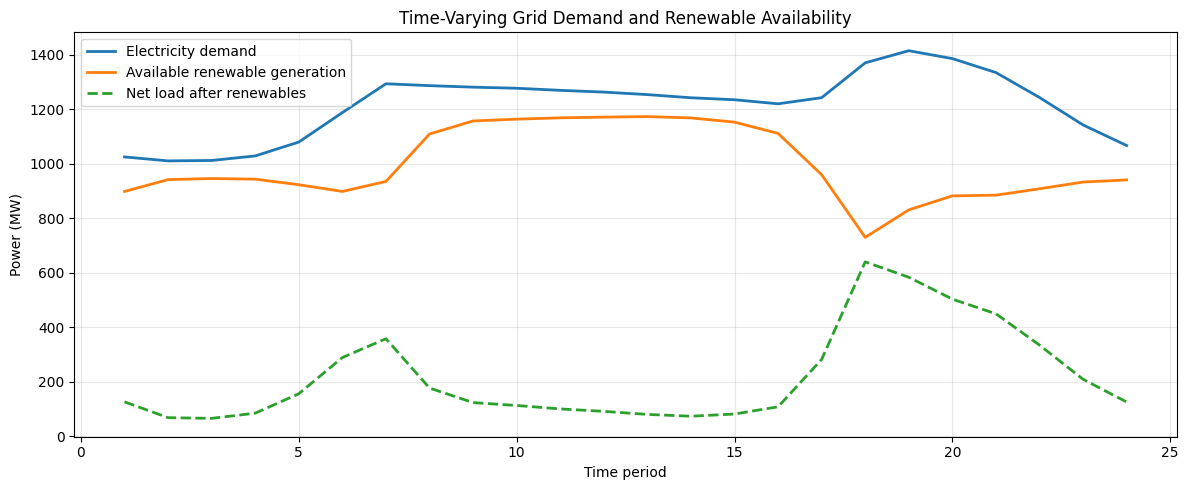

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    profile["Period"], profile["Demand_MW"],
    label="Electricity demand", linewidth=2
)

plt.plot(
    profile["Period"], profile["Renewable_MW"],
    label="Available renewable generation", linewidth=2
)

plt.plot(
    profile["Period"], profile["Net_Load_MW"],
    label="Net load after renewables",
    linewidth=2, linestyle="--"
)

plt.xlabel("Time period")
plt.ylabel("Power (MW)")
plt.title("Time-Varying Grid Demand and Renewable Availability")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Classical Multi-Period Unit Commitment

The expanded scheduling problem is formulated as a mixed-integer linear program (MILP) and solved using SciPy's HiGHS optimiser.

The model includes generator commitment, startup and shutdown decisions, continuous power dispatch, and piecewise-linear production costs.

Unlike the single-period experiment, it enforces time-linked ramping constraints and minimum ON/OFF durations.

The objective is to minimise total operating and startup costs across all 24 periods while satisfying demand, reserve, and generator operating constraints.

The full implementation is located in `src/multi_period_milp.py`.

The resulting thermal schedules, renewable dispatch, curtailment values, optimisation summary, and generation plots are exported to `results/multi_period/`.

In [8]:
%run ../src/multi_period_milp.py

Model: 20 thermal, 7 renewable, 24 periods
MILP variables: 3528; binary: 1440; constraints: 3888
Solving with HiGHS...
Solver status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Objective: 166,249.36 benchmark cost units
Solve time: 4.05s; reported MIP gap: 0.000605825631566379
Total curtailed power summed over periods: 795.71 MW-periods
Saved results to C:\Users\devan\OneDrive\Documents\Learning_code\Qiskit_Grid_Optimization\results\multi_period
 period  demand_mw  thermal_mw  renewable_used_mw  curtailed_mw  generators_on
      1    1024.82      154.00             870.82         27.28              3
      2    1010.26      154.00             856.26         85.34              3
      3    1011.82      154.00             857.82         87.78              3
      4    1028.50      154.00             874.50         68.80              3
      5    1079.31      156.41             922.90          0.00              3
      6    1187.40      289.20             898.20      

## Time-Dependent Quantum Optimisation

Direct QAOA simulation of the complete 20-generator, 24-period commitment problem is computationally impractical.

Instead, we construct a conditional subproblem involving four thermal generators across three consecutive periods (periods 16–18), while fixing the remaining generators according to the classical MILP schedule.

This produces 12 binary commitment variables, requiring 12 qubits.

The QUBO incorporates approximate generation costs, time-dependent startup costs, and capacity-adequacy penalties. Standard QAOA and CVaR-QAOA are implemented in Qiskit and compared using physical operating costs and constraint feasibility.

All 4,096 possible commitment schedules are classically enumerated to establish an exact reference solution for this conditional subproblem.

The implementation is located in `src/temporal_qaoa.py`, and the outputs are saved to `results/temporal_quantum/`.

**Limitations:** The quantum QUBO does not exactly encode every physical constraint, so separate classical feasibility checks are essential. The experiment demonstrates a hybrid quantum-classical scheduling approach, not quantum speedup or full quantum optimisation of the 24-period grid.

In [10]:
%run ../src/temporal_qaoa.py

Conditional quantum problem: 4 thermal units x 3 periods = 12 bits
Selected thermal: ['202_STEAM_3', '101_STEAM_4', '115_STEAM_3', '315_CT_7'] ; periods: (16, 17, 18)
   period    demand_mw  renewable_available_mw  fixed_other_thermal_mw  \
0      16  1219.622854                  1111.0                   124.0   
1      17  1242.052498                   959.7                   190.0   
2      18  1369.866909                   729.8                   318.0   

   reserve_mw  
0   36.588686  
1   37.261575  
2   41.096007  
QUBO optimum: 111011111001 energy=-6,729.0
LP enumeration time: 0.46 s
Physically feasible schedules: 10 / 4096
Exact classical optimum: 111011011011 cost: 40103.16
QUBO optimum physically feasible: True
QUBO optimum physical cost: 41342.09; gap: 3.09%
Standard QAOA 
 {
  "method": "Standard QAOA",
  "depth": 1,
  "qubits": 12,
  "optimization_seconds": 0.7798546999983955,
  "function_evaluations": 148,
  "probability_exact_qubo_optimum": 0.008032350302917653,
  "prob